In [1]:
import os
import pandas as pd
import numpy as np
import random
import pickle
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime
from tqdm import tqdm
from sklearn.metrics import r2_score
from collections import OrderedDict

# from ucimlrepo import fetch_ucirepo 

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split

from data.data_loader import EPCDataset, PowerWeatherDatasetWithSeason, PowerWeatherDataset, SingleTermDataset, MultiTermDataset
from models.lstm import LSTMModel
from models.lstm_attention import LSTMWithAttention, BiLSTMWithAttention
from models.gru import GRUModel
from models.utils import create_model, train_for_short_term_forecast, train_for_long_term_forecast, load_model, evaluate_for_short_term_forecast, evaluate_for_long_term_forecast

from explainers.utils import get_explainer

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# short term 
features_for_1h = [
    'Global_active_power',
    'Global_intensity',
    'Sub_metering_1', 
    'Sub_metering_2', 
    'Sub_metering_3', 
    'Temperature',	
    'Humidity',	
]

# long term
features_for_6h = [
    'Global_active_power',
    'Global_intensity',
    'Sub_metering_1', 
    'Sub_metering_2', 
    'Sub_metering_3', 
    'Temp_Min',	'Temp_Max', 'Temp_Avg',	'Temp_Range',
    'Humidity_Min',	'Humidity_Max',	'Humidity_Avg',	'Humidity_Range'
]

file_path_for_1h = 'data/final_data.csv'
file_path_for_6h = 'data/final_data_per_6hr_with_avg_range.csv'

dataset_params = {
    # for long-term forecast 

    # 'long_term_length' : 365*4, # 6시간 단위 1년 데이터
    'long_term_length' : 90*24,
    'long_term_pred_length' : 256, # 64, 128, 256
    
    'short_term_length' : 30*24, # 1시간 단위 한달 데이터
    'short_term_pred_length' : 7*24, # 일주일 데이터 예측

    # 2. LSTM, GRU, CNN-LSTM  -> 365*24 / 7*24 (비교용)
    # for Short-term forecast 
    'sequence_length' : 24*30,  # -> 일주일 / 10일 / 15일 / 한달  
    'prediction_length' : 24
}


is_long_term_forecast = True

Using device: cuda


In [2]:
def load_dataset_new_features(params, 
                              important_features_for_long, 
                              important_features_for_short, 
                              is_long_term_forecast=True):
    selected_features = dict()
    
    if is_long_term_forecast:
        dataset_1h_long = EPCDataset(
            file_path=file_path_for_1h,
            sequence_length=params['long_term_length'],  
            prediction_length=params['long_term_pred_length'],
            target_features=important_features_for_long
        )
        train_long, train_targets_long, eval_long, eval_targets_long = dataset_1h_long.load_data()
        
        dataset_1h_short = EPCDataset(
            file_path=file_path_for_1h,
            sequence_length=params['short_term_length'],  
            prediction_length=params['short_term_pred_length'],
            target_features=important_features_for_short
        )
        train_short, train_targets_short, eval_short, eval_targets_short = dataset_1h_short.load_data()
        
        train_data=(train_long, train_short)
        train_targets=(train_targets_long, train_targets_short)
        eval_data=(eval_long, eval_short)
        eval_targets=(eval_targets_long, eval_targets_short)

        selected_features['long'] = dataset_1h_long.selected_features
        selected_features['short'] = dataset_1h_short.selected_features

    else:
        dataset_1h = EPCDataset(
            file_path=file_path_for_1h,
            sequence_length=params['sequence_length'],  
            prediction_length=params['prediction_length'],
            target_features=important_features_for_short
        )
        
        train_sequence, train_targets_sequence, eval_sequence, eval_targets_sequence = dataset_1h.load_data()

        train_data=train_sequence
        train_targets=train_targets_sequence
        eval_data=eval_sequence
        eval_targets=eval_targets_sequence
    
        selected_features['short'] = dataset_1h.selected_features

    return train_data, train_targets, eval_data, eval_targets, selected_features

In [3]:
train_data, train_targets, eval_data, eval_targets, selected_features = load_dataset_new_features(
    params=dataset_params,
    important_features_for_long=features_for_1h,
    important_features_for_short=features_for_1h,
    is_long_term_forecast=is_long_term_forecast
)

In [6]:
print(train_data[0].shape)

torch.Size([22588, 2160, 13])


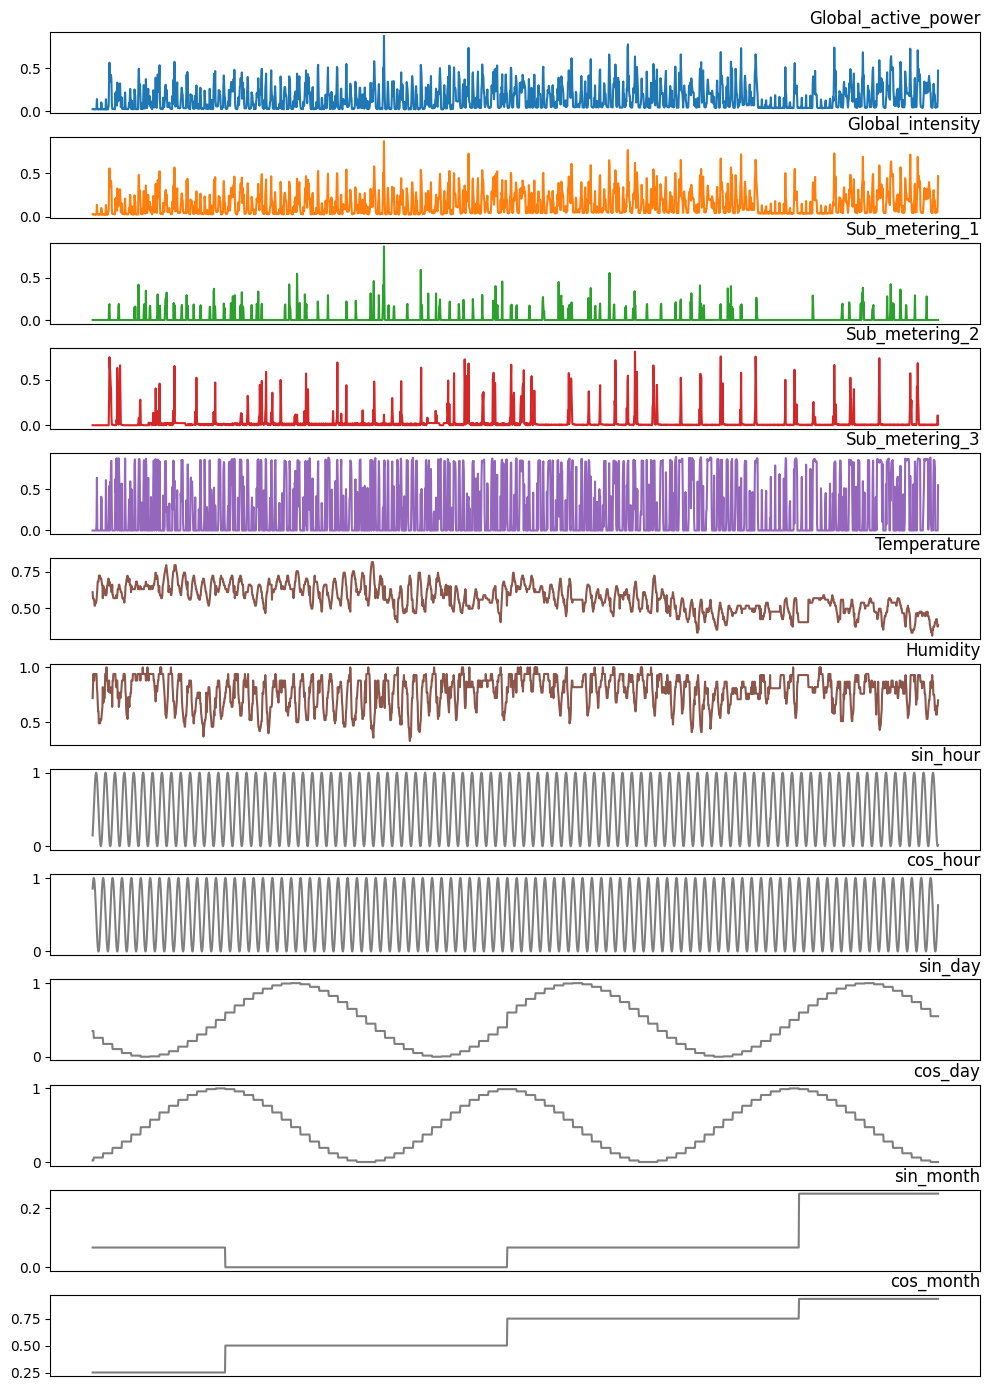

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# 예시: train_data[0]의 첫 번째 샘플 (시퀀스 길이 x feature 수)
sample_data = train_data[0][0].numpy()  # shape: (2160, 13)

selected_feature_names = [
    'Global_active_power', 'Global_intensity',
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3',
    'Temperature', 'Humidity',
    'sin_hour', 'cos_hour', 'sin_day', 'cos_day', 'sin_month', 'cos_month'
]

# 색상 매핑
color_map = {
    'Global_active_power': 'tab:blue',
    'Global_intensity': 'tab:orange',
    'Sub_metering_1': 'tab:green',
    'Sub_metering_2': 'tab:red',
    'Sub_metering_3': 'tab:purple',
    'Temperature': 'tab:brown',
    'Humidity': 'tab:brown',
    'sin_hour': 'tab:gray', 'cos_hour': 'tab:gray',
    'sin_day': 'tab:gray', 'cos_day': 'tab:gray',
    'sin_month': 'tab:gray', 'cos_month': 'tab:gray'
}

plt.figure(figsize=(12, 14))
for i, feature_name in enumerate(selected_feature_names):
    plt.subplot(len(selected_feature_names), 1, i + 1)
    plt.plot(sample_data[:, i], color=color_map[feature_name])
    plt.title(feature_name, fontsize=12, loc='right')
    plt.xticks([])



plt.subplots_adjust(hspace=0.3, top=0.98, bottom=0.02)  # 서브플롯 간 간격 조정

plt.savefig('visualization.png')
plt.show()


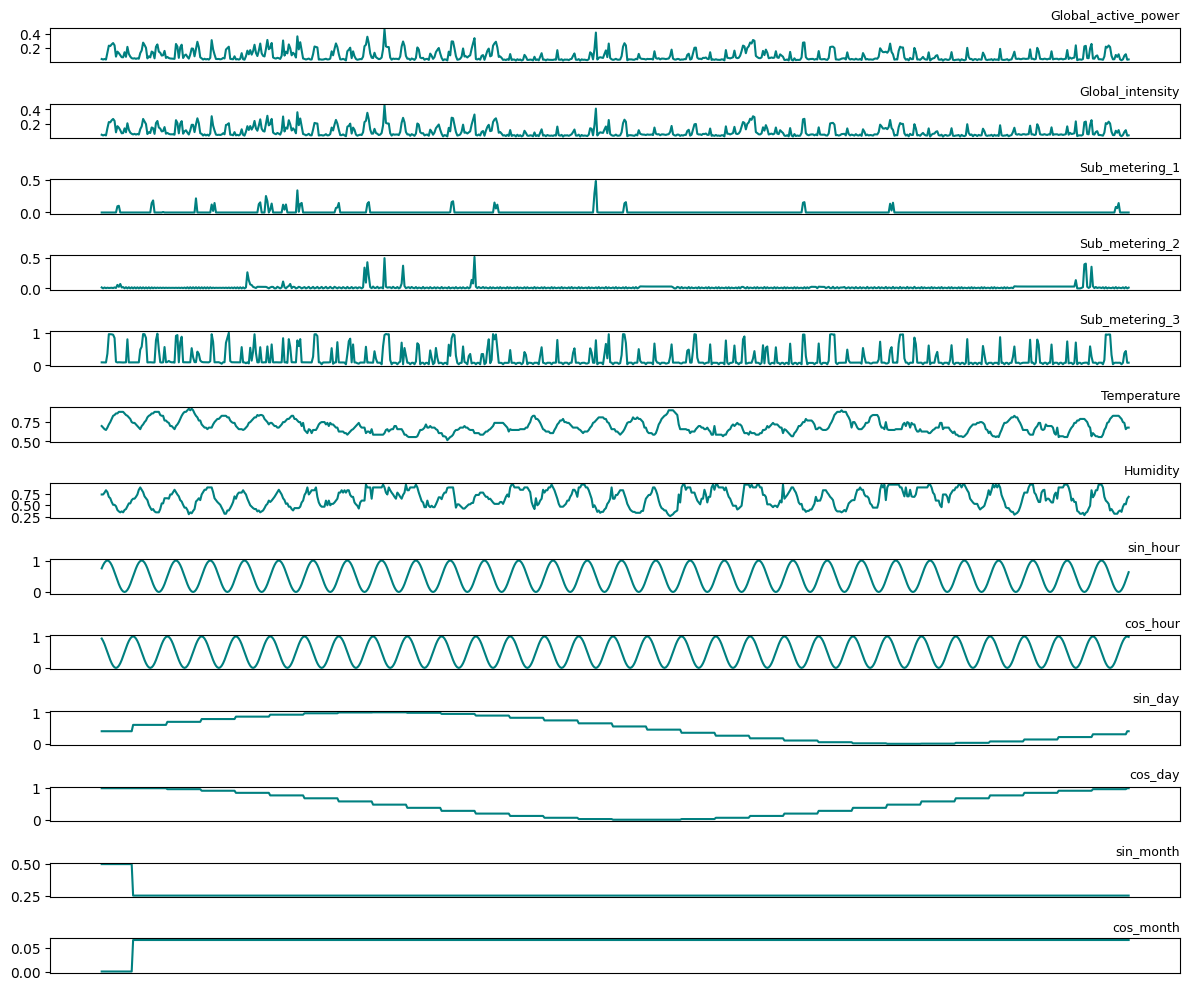